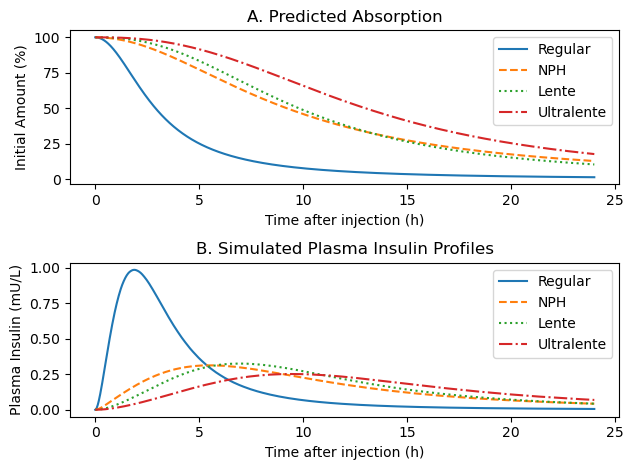

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters for each insulin type
params = {
    'regular': [2.0, 0.05, 1.7],
    'NPH': [2.0, 0.18, 4.9],
    'lente': [2.4, 0.15, 6.2],
    'ultralente': [2.5, 0.0, 13.0]
}

# Common parameters
dose = 24  # Insulin dose
k_e = 5.4  # Elimination rate constant
t = np.linspace(0, 24, 1000)  # Time from 0 to 24 hours

# Initialize results
absorption_curves = []
plasma_curves = []
plasma_concentration = []
# Loop over each insulin type
for insulin_type, (s, a, b) in params.items():
    # Calculate T_50
    T_50 = a * dose + b

    # Absorption curve
    A_abs = 100 / (1 + (t / T_50)**s)
    absorption_curves.append(A_abs)

    # Plasma insulin (solve ODE)
    def plasma_insulin_ode(t, A):
        absorption_rate = (s * t**(s-1) *(T_50)**s * dose) / ((T_50**s + t**s)**2)
        return absorption_rate - k_e * A

    # Solve ODE for plasma insulin
    sol = solve_ivp(plasma_insulin_ode, [0, 24], [0], t_eval=t)

    plasma_curves.append(sol.y[0])
   
   
# Convert lists to numpy arrays for easier indexing
absorption_curves = np.array(absorption_curves)
plasma_curves = np.array(plasma_curves)

# Plot Figure 2A (Absorption)
#plt.figure(figsize=(10, 8))

# Panel A
plt.subplot(2, 1, 1)
plt.plot(t, absorption_curves[0, :], '-', label='Regular')
plt.plot(t, absorption_curves[1, :], '--', label='NPH')
plt.plot(t, absorption_curves[2, :], ':', label='Lente')
plt.plot(t, absorption_curves[3, :], '-.', label='Ultralente')
plt.xlabel('Time after injection (h)')
plt.ylabel('Initial Amount (%)')
plt.title('A. Predicted Absorption')
plt.legend()

# Panel B
plt.subplot(2, 1, 2)
plt.plot(t, plasma_curves[0, :], '-', label='Regular')
plt.plot(t, plasma_curves[1, :], '--', label='NPH')
plt.plot(t, plasma_curves[2, :], ':', label='Lente')
plt.plot(t, plasma_curves[3, :], '-.', label='Ultralente')
plt.xlabel('Time after injection (h)')
plt.ylabel('Plasma Insulin (mU/L)')
plt.title('B. Simulated Plasma Insulin Profiles')
plt.legend()

# Show plot
plt.tight_layout()
plt.show()


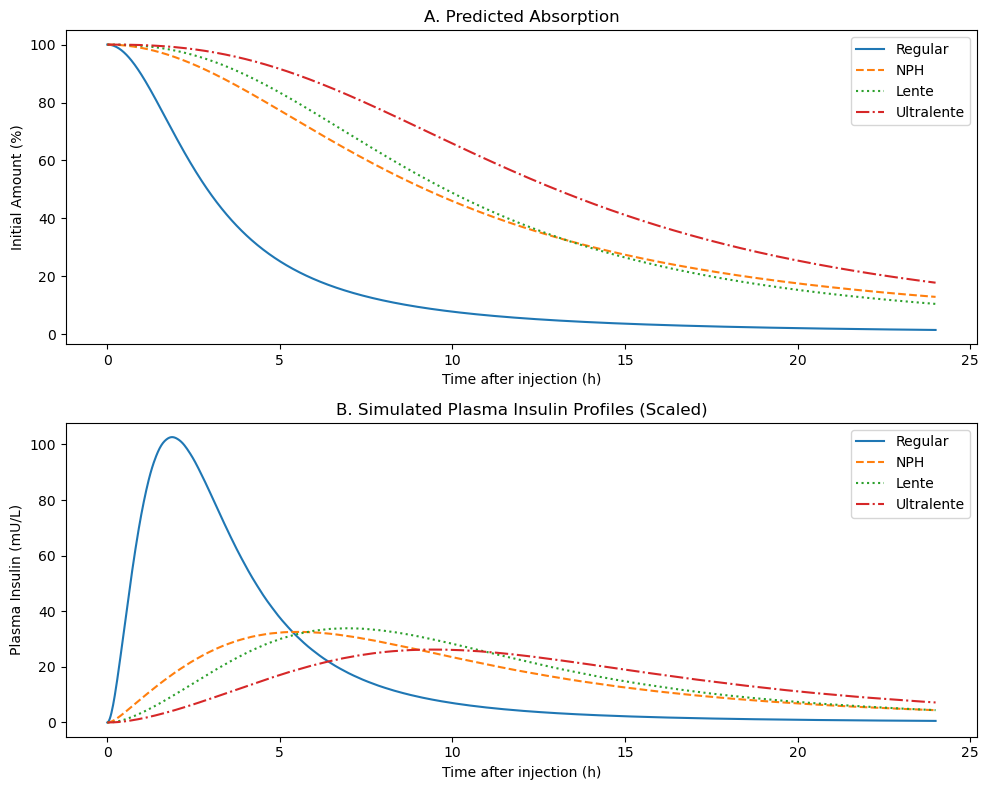

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters for each insulin type
params = {
    'regular': [2.0, 0.05, 1.7],
    'NPH': [2.0, 0.18, 4.9],
    'lente': [2.4, 0.15, 6.2],
    'ultralente': [2.5, 0.0, 13.0]
}

# Common parameters
dose = 24  # Insulin dose
k_e = 5.4  # Elimination rate constant
t = np.linspace(0, 24, 1000)  # Time from 0 to 24 hours

# Initialize results
absorption_curves = []
plasma_curves = []
plasma_concentration = []
# Loop over each insulin type
for insulin_type, (s, a, b) in params.items():
    # Calculate T_50
    T_50 = a * dose + b

    # Absorption curve
    A_abs = 100 / (1 + (t / T_50)**s)
    absorption_curves.append(A_abs)

    # Plasma insulin (solve ODE)
    def plasma_insulin_ode(t, A): #in the paper its t^s instead of t^s-1
        absorption_rate = (s * t**(s-1) *(T_50)**s * dose) / ((T_50**s + t**s)**2)
        return absorption_rate - k_e * A

    # Solve ODE for plasma insulin
    sol = solve_ivp(plasma_insulin_ode, [0, 24], [0], t_eval=t)

    plasma_curves.append(sol.y[0]/12) #

# Convert lists to numpy arrays for easier indexing
absorption_curves = np.array(absorption_curves)
plasma_curves = np.array(plasma_curves)

# Scaling factor to adjust plasma insulin range (0-12 to 0-120)
scaling_factor = 1250  #scaling factor included to make more similar to paper. Temporary
plasma_curves_scaled = plasma_curves * scaling_factor

# Plot Figure 2A (Absorption)
plt.figure(figsize=(10, 8))

# Panel A: Absorption (no scaling required here)
plt.subplot(2, 1, 1)
plt.plot(t, absorption_curves[0, :], '-', label='Regular')
plt.plot(t, absorption_curves[1, :], '--', label='NPH')
plt.plot(t, absorption_curves[2, :], ':', label='Lente')
plt.plot(t, absorption_curves[3, :], '-.', label='Ultralente')
plt.xlabel('Time after injection (h)')
plt.ylabel('Initial Amount (%)')
plt.title('A. Predicted Absorption')
plt.legend()

# Panel B: Plasma insulin (scaled values)
plt.subplot(2, 1, 2)
plt.plot(t, plasma_curves_scaled[0, :], '-', label='Regular')
plt.plot(t, plasma_curves_scaled[1, :], '--', label='NPH')
plt.plot(t, plasma_curves_scaled[2, :], ':', label='Lente')
plt.plot(t, plasma_curves_scaled[3, :], '-.', label='Ultralente')
plt.xlabel('Time after injection (h)')
plt.ylabel('Plasma Insulin (mU/L)')
plt.title('B. Simulated Plasma Insulin Profiles (Scaled)')
plt.legend()
#plt.ylim(0,120)

# Show plot
plt.tight_layout()
plt.show()


/var/folders/3h/6m483x5j6l349p0wtj7ytzxc0000gn/T/ipykernel_79008/1879999467.py:41: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 512, calc_second_order=False)
/var/folders/3h/6m483x5j6l349p0wtj7ytzxc0000gn/T/ipykernel_79008/1879999467.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(plasma, t)


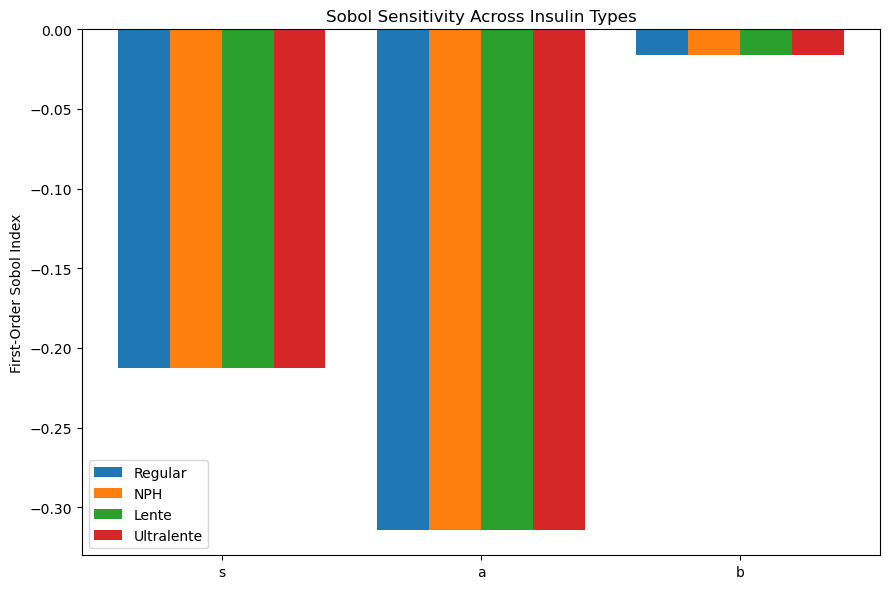


Regular Sobol Sensitivity:
  s: S1=-0.213, ST=0.449
  a: S1=-0.314, ST=0.841
  b: S1=-0.016, ST=1.149

NPH Sobol Sensitivity:
  s: S1=-0.213, ST=0.449
  a: S1=-0.314, ST=0.841
  b: S1=-0.016, ST=1.149

Lente Sobol Sensitivity:
  s: S1=-0.213, ST=0.449
  a: S1=-0.314, ST=0.841
  b: S1=-0.016, ST=1.149

Ultralente Sobol Sensitivity:
  s: S1=-0.213, ST=0.449
  a: S1=-0.314, ST=0.841
  b: S1=-0.016, ST=1.149


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from SALib.sample import saltelli
from SALib.analyze import sobol

# -------------------------------------------------
# Sobol Sensitivity Analysis for Multiple Insulin Types
# -------------------------------------------------

# Parameters for each insulin type: [s, a, b]
insulin_params = {
    'Regular': [2.0, 0.05, 1.7],
    'NPH': [2.0, 0.18, 4.9],
    'Lente': [2.4, 0.15, 6.2],
    'Ultralente': [2.5, 0.00, 13.0]
}

dose = 24
k_e = 5.4
t = np.linspace(0, 24, 1000)

# Define Sobol problem
problem = {
    'num_vars': 3,
    'names': ['s', 'a', 'b'],
    'bounds': [[1.5, 2.6], [0.02, 0.20], [1.0, 14.0]]
}

def plasma_model_output(s, a, b):
    """Compute total plasma insulin exposure (AUC)."""
    T_50 = a * dose + b
    def plasma_insulin_ode(t, A):
        absorption_rate = (s * t**(s-1) * (T_50)**s * dose) / ((T_50**s + t**s)**2)
        return absorption_rate - k_e * A
    sol = solve_ivp(plasma_insulin_ode, [0, 24], [0], t_eval=t)
    plasma = sol.y[0] / 12
    return np.trapz(plasma, t)

# Generate parameter samples (same for all insulin types)
param_values = saltelli.sample(problem, 512, calc_second_order=False)

results = {}

for insulin, (s0, a0, b0) in insulin_params.items():
    Y = np.array([plasma_model_output(*p) for p in param_values])
    Si = sobol.analyze(problem, Y, print_to_console=False)
    results[insulin] = Si

# -------------------
# Plot comparison (First-order indices)
# -------------------
param_names = problem['names']
x = np.arange(len(param_names))
bar_width = 0.2

plt.figure(figsize=(9, 6))
for i, (insulin, Si) in enumerate(results.items()):
    offsets = x + (i - 1.5) * bar_width
    plt.bar(offsets, Si['S1'], width=bar_width, label=insulin)

plt.xticks(x, param_names)
plt.ylabel('First-Order Sobol Index')
plt.title('Sobol Sensitivity Across Insulin Types')
plt.legend()
plt.tight_layout()
plt.show()

# Print results in readable format
for insulin, Si in results.items():
    print(f"\n{insulin} Sobol Sensitivity:")
    for name, S1, ST in zip(problem['names'], Si['S1'], Si['ST']):
        print(f"  {name}: S1={S1:.3f}, ST={ST:.3f}")


/var/folders/3h/6m483x5j6l349p0wtj7ytzxc0000gn/T/ipykernel_79008/2394024694.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(plasma, t)
/var/folders/3h/6m483x5j6l349p0wtj7ytzxc0000gn/T/ipykernel_79008/2394024694.py:51: RuntimeWarning: invalid value encountered in scalar divide
  sens = ((increased - decreased) / (2 * base_value * perturb)) * 100


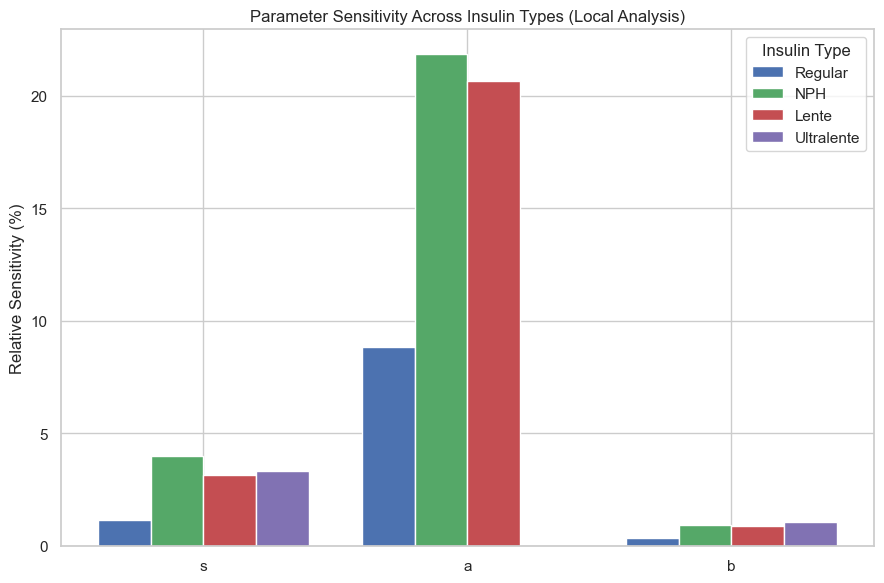


Regular Sensitivity:
  s: 1.15% change per 1% parameter change
  a: -8.82% change per 1% parameter change
  b: -0.37% change per 1% parameter change

NPH Sensitivity:
  s: 3.99% change per 1% parameter change
  a: -21.86% change per 1% parameter change
  b: -0.91% change per 1% parameter change

Lente Sensitivity:
  s: 3.13% change per 1% parameter change
  a: -20.65% change per 1% parameter change
  b: -0.86% change per 1% parameter change

Ultralente Sensitivity:
  s: 3.32% change per 1% parameter change
  a: nan% change per 1% parameter change
  b: -1.05% change per 1% parameter change


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -------------------------------------------------
# Local Sensitivity Analysis Across Insulin Types
# -------------------------------------------------

# Parameters for each insulin type: [s, a, b]
insulin_params = {
    'Regular': [2.0, 0.05, 1.7],
    'NPH': [2.0, 0.18, 4.9],
    'Lente': [2.4, 0.15, 6.2],
    'Ultralente': [2.5, 0.00, 13.0]
}

dose = 24
k_e = 5.4
t = np.linspace(0, 24, 1000)
perturb = 0.1  # ±10% perturbation

def plasma_model_output(s, a, b):
    """Compute total plasma insulin exposure (AUC)."""
    T_50 = a * dose + b

    def plasma_insulin_ode(t, A):
        absorption_rate = (s * t**(s-1) * (T_50)**s * dose) / ((T_50**s + t**s)**2)
        return absorption_rate - k_e * A

    sol = solve_ivp(plasma_insulin_ode, [0, 24], [0], t_eval=t)
    plasma = sol.y[0] / 12
    return np.trapz(plasma, t)

# Perform local sensitivity analysis
results = {}
for name, (s_base, a_base, b_base) in insulin_params.items():
    baseline = plasma_model_output(s_base, a_base, b_base)
    params = {'s': s_base, 'a': a_base, 'b': b_base}
    sensitivities = {}

    for param, base_value in params.items():
        # Increase and decrease by 10%
        new_params = params.copy()
        new_params[param] = base_value * (1 + perturb)
        increased = plasma_model_output(**new_params)

        new_params[param] = base_value * (1 - perturb)
        decreased = plasma_model_output(**new_params)

        # Central finite difference approximation (% change per 1% parameter change)
        sens = ((increased - decreased) / (2 * base_value * perturb)) * 100
        sensitivities[param] = sens

    results[name] = sensitivities

# -------------------
# Plot comparison
# -------------------
param_names = ['s', 'a', 'b']
bar_width = 0.2
x = np.arange(len(param_names))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']

plt.figure(figsize=(9, 6))
for i, (insulin, sens) in enumerate(results.items()):
    offsets = x + (i - 1.5) * bar_width
    plt.bar(offsets, np.abs(list(sens.values())),
             width=bar_width, label=insulin, color=colors[i])

plt.xticks(x, param_names)
plt.ylabel('Relative Sensitivity (%)')
plt.title('Parameter Sensitivity Across Insulin Types (Local Analysis)')
plt.legend(title='Insulin Type')
plt.tight_layout()
plt.show()

# Print numeric results
for insulin, sens in results.items():
    print(f"\n{insulin} Sensitivity:")
    for p, v in sens.items():
        print(f"  {p}: {v:.2f}% change per 1% parameter change")


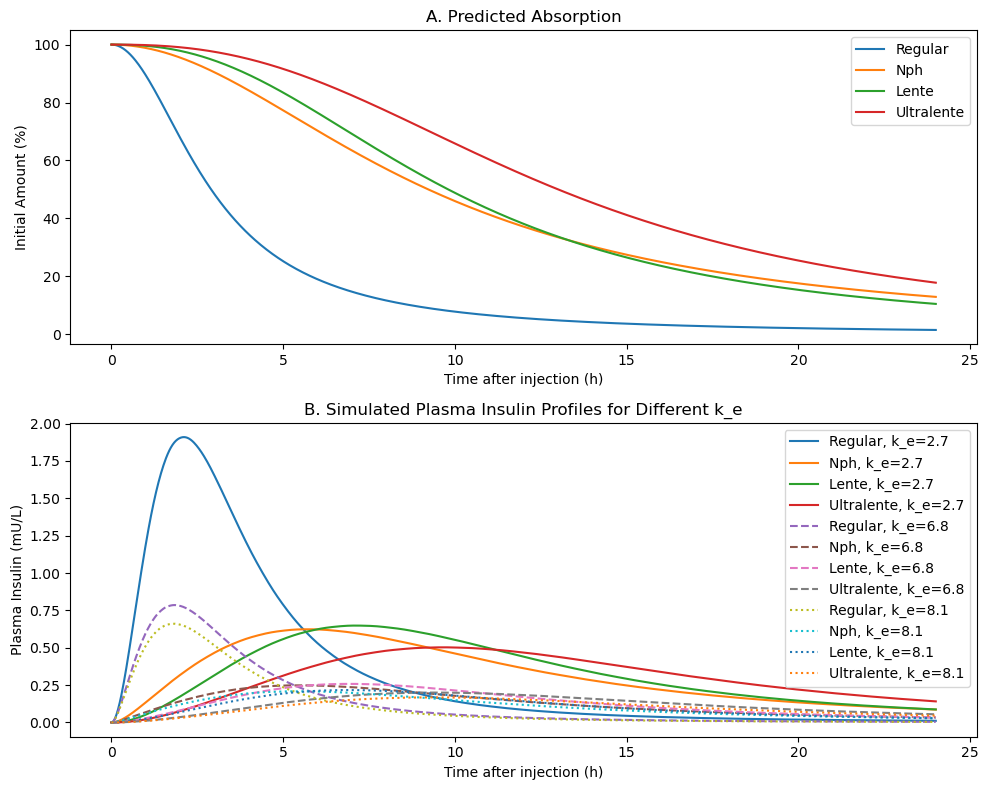

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters for each insulin type
params = {
    'regular': [2.0, 0.05, 1.7],
    'NPH': [2.0, 0.18, 4.9],
    'lente': [2.4, 0.15, 6.2],
    'ultralente': [2.5, 0.0, 13.0]
}

# Common parameters
dose = 24  # Insulin dose
k_e_values = [2.7,6.8,8.1]  # Range of k_e values for sensitivity analysis
t = np.linspace(0, 24, 1000)  # Time from 0 to 24 hours

# Initialize results
absorption_curves = []
plasma_curves_by_ke = {k_e: [] for k_e in k_e_values}

# Loop over each insulin type
for insulin_type, (s, a, b) in params.items():
    # Calculate T_50
    T_50 = a * dose + b

    # Absorption curve
    A_abs = 100 / (1 + (t / T_50)**s)
    absorption_curves.append(A_abs)

    # Loop over different k_e values
    for k_e in k_e_values:
        # Plasma insulin (solve ODE)
        def plasma_insulin_ode(t, A):
            absorption_rate = (s * t**(s-1) * (T_50)**s * dose) / ((T_50**s + t**s)**2)
            return absorption_rate - k_e * A

        # Solve ODE for plasma insulin
        sol = solve_ivp(plasma_insulin_ode, [0, 24], [0], t_eval=t)

        # Store results for this k_e
        plasma_curves_by_ke[k_e].append(sol.y[0])

# Convert lists to numpy arrays for easier indexing
absorption_curves = np.array(absorption_curves)

# Plotting results
plt.figure(figsize=(10, 8))

# Panel A: Absorption (no scaling required here)
plt.subplot(2, 1, 1)
for i, insulin_type in enumerate(params.keys()):
    plt.plot(t, absorption_curves[i, :], label=insulin_type.capitalize())
plt.xlabel('Time after injection (h)')
plt.ylabel('Initial Amount (%)')
plt.title('A. Predicted Absorption')
plt.legend()

# Panel B: Plasma insulin for different k_e values
plt.subplot(2, 1, 2)
line_styles = ['-', '--', ':']
for k_idx, (k_e, line_style) in enumerate(zip(k_e_values, line_styles)):
    for i, insulin_type in enumerate(params.keys()):
        plt.plot(
            t, 
            plasma_curves_by_ke[k_e][i], 
            line_style, 
            label=f'{insulin_type.capitalize()}, k_e={k_e}'
        )
plt.xlabel('Time after injection (h)')
plt.ylabel('Plasma Insulin (mU/L)')
plt.title('B. Simulated Plasma Insulin Profiles for Different k_e')
plt.legend()
plt.tight_layout()
plt.show()


In [47]:
import sympy as sp

# Define symbolic variables
A, G, I_r = sp.symbols('A G I_r')  # State variables: Plasma insulin (A), plasma glucose (G), remote insulin (I_r)
C_in, D, k_e, c, d, Km, G_x, V_G, V_I, k1, k2 = sp.symbols('C_in D k_e c d Km C_x V_G V_I k1 k2')  # Parameters
t, epsilon = sp.symbols('t epsilon')  # Time and small constant

# Define the differential equations
T50 = a * D + b
dA_dt = (s * (t**s) * (T50**s) * D) / (t * ((T50**s + t**s)**2)) - k_e * A
# Plasma glucose dynamics
Vmax = c * I_r + d
Cout = (Vmax * G) / (Km + G)
dC_dt = C_in - Cout
#dG_dt = C_in - Cout
dG_dt = (C_in - ((c * I_r + d) * (Km + G) / (Km + G_x))) / V_G
dI_r_dt = k1 *(A/V_I) - k2 * I_r
# Remote insulin dynamics
#dI_r_dt = k1 * (A / V_I) - k2 * I_r

# Plasma insulin dynamics



# Combine into a list
equations = [dA_dt, dG_dt, dI_r_dt]

# Define the variables for the Jacobian matrix
variables = [A, G, I_r]

# Compute the Jacobian matrix
Jacobian = sp.Matrix([[sp.diff(eq, var) for var in variables] for eq in equations])

# Simplify the Jacobian matrix
Jacobian_simplified = sp.simplify(Jacobian)

# Define steady-state variables
A_s, G_s, I_r_s = sp.symbols('A_s G_s I_r_s')  # Steady-state values
steady_state_subs = {A: A_s, G: G_s, I_r: I_r_s, t: 1, epsilon: 1e-6}

# Evaluate the Jacobian at the steady state
Jacobian_evaluated = Jacobian_simplified.subs(steady_state_subs)

# Solve for eigenvalues of the Jacobian
eigenvalues = Jacobian_evaluated.eigenvals()

# Print the Jacobian and eigenvalues
print("Jacobian Matrix at Steady State:")
sp.pprint(Jacobian_evaluated)

print("\nEigenvalues of the Jacobian Matrix:")
for eigenvalue, multiplicity in eigenvalues.items():
    print(f"Eigenvalue: {eigenvalue}, Multiplicity: {multiplicity}")


Jacobian Matrix at Steady State:
⎡-kₑ        0              0      ⎤
⎢                                 ⎥
⎢      -Iᵣ ₛ⋅c - d   -c⋅(Gₛ + Km) ⎥
⎢ 0   ─────────────  ─────────────⎥
⎢     V_G⋅(Cₓ + Km)  V_G⋅(Cₓ + Km)⎥
⎢                                 ⎥
⎢ k₁                              ⎥
⎢───        0             -k₂     ⎥
⎣V_I                              ⎦

Eigenvalues of the Jacobian Matrix:
Eigenvalue: -k_e, Multiplicity: 1
Eigenvalue: -k2, Multiplicity: 1
Eigenvalue: -(I_r_s*c + d)/(V_G*(C_x + Km)), Multiplicity: 1


In [14]:
import sympy as sp

# Define symbolic variables
A, G, Ia = sp.symbols('A G I_a')  # State variables: Plasma insulin (A), Plasma glucose (C), Active insulin (Ia)
s, a, b, ke, D, Km, c, d, k1, k2, Cin = sp.symbols('s a b ke D Km c d k1 k2 Cin')  # Parameters

# Define T50 symbolically
T50 = a * D + b

# Define the equations symbolically
# Plasma insulin dynamics
dA_dt = (s * (T50**s) * (T50**s) * D) / (T50 * ((T50**s + T50**s)**2)) - ke * A

# Glucose dynamics
Vmax = c * Ia + d
Cout = (Vmax * G) / (Km + G)
dC_dt = Cin - Cout

# Insulin action delay
dIa_dt = k1 * A - k2 * Ia

# Create a vector of equations
equations = sp.Matrix([dA_dt, dC_dt, dIa_dt])

# Create a vector of variables
variables = sp.Matrix([A, G, Ia])

# Calculate the Jacobian matrix
jacobian = equations.jacobian(variables)

# Display the Jacobian matrix
jacobian


Matrix([
[-ke,                                                0,             0],
[  0, G*(I_a*c + d)/(G + Km)**2 - (I_a*c + d)/(G + Km), -G*c/(G + Km)],
[ k1,                                                0,           -k2]])

In [23]:
import sympy as sp
from scipy.optimize import fsolve
import numpy as np

# Define symbolic variables
A, C, I_e = sp.symbols('A C I_e')  # State variables
s, a, b, ke, D, Km, c, d, k1, k2, Cin, V_I = sp.symbols('s a b ke D Km c d k1 k2 Cin V_I')  # Parameters

# Define T50 symbolically
T50 = a * D + b

# Plasma insulin dynamics
dA_dt = (s * (T50**s) * (T50**s) * D) / (T50 * ((T50**s + T50**s)**2)) - ke * A

# Glucose dynamics
Vmax = c * I_e + d
Cout = (Vmax * C) / (Km + C)
dC_dt = Cin - Cout

# Insulin action delay
dI_e_dt = k1 * A / V_I - k2 * I_e

# Create equations and Jacobian
equations = sp.Matrix([dA_dt, dC_dt, dI_e_dt])
variables = sp.Matrix([A, C, I_e])
jacobian = equations.jacobian(variables)

print(jacobian)

# Convert symbolic Jacobian to numerical function
jacobian_func = sp.lambdify((A, C, I_e, s, a, b, ke, D, Km, c, d, k1, k2, Cin, V_I), jacobian)

# Define the system of equations for fsolve
def system_equations(variables):
    """
    System of equations with exact parameters.
    """
    A, C, I_e = variables

    # Parameters
    s = 2.0
    a = 0.05
    b = 1.7
    ke = 5.4
    D = 24.0
    Km = 180.0
    c = 0.045
    d = 1.62
    k1 = 0.025
    k2 = 1.25
    Cin = 100.0
    V_I = 12.0

    # T50 calculation
    T50 = a * D + b

    # Plasma insulin dynamics
    dA_dt = (s * (T50**s) * (T50**s) * D) / (T50 * ((T50**s + T50**s)**2)) - ke * A

    # Glucose dynamics
    Vmax = c * I_e + d
    Cout = (Vmax * C) / (Km + C)
    dC_dt = Cin - Cout

    # Insulin action delay
    dI_e_dt = k1 * A / V_I - k2 * I_e

    return [dA_dt, dC_dt, dI_e_dt]

# Solve for equilibrium points
initial_guess = [0.0, 100.0, 0.0]
equilibrium = fsolve(system_equations, initial_guess)

# Extract equilibrium values
A_eq, C_eq, I_e_eq = equilibrium

# Evaluate the Jacobian matrix at the equilibrium points
jacobian_evaluated = jacobian_func(
    A_eq, C_eq, I_e_eq,
    2.0, 0.05, 1.7, 0.054, 24.0, 180.0, 0.045, 1.62, 0.025, 1.25, 100.0, 12.0
)

# Convert the evaluated Jacobian to a numerical array
jacobian_numeric = np.array(jacobian_evaluated, dtype=float)

# Compute the eigenvalues of the Jacobian matrix
eigenvalues = np.linalg.eigvals(jacobian_numeric)

# Display results
print("Equilibrium point (A, C, I_e):", equilibrium)
print("Jacobian matrix at equilibrium points:")
print(jacobian_numeric)
print("Eigenvalues of the Jacobian matrix:")
print(eigenvalues)



Matrix([[-ke, 0, 0], [0, C*(I_e*c + d)/(C + Km)**2 - (I_e*c + d)/(C + Km), -C*c/(C + Km)], [k1/V_I, 0, -k2]])
Equilibrium point (A, C, I_e): [7.66211827e-01 5.12734277e+06 2.77977946e+00]
Jacobian matrix at equilibrium points:
[[-5.40000000e-02  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -1.19474483e-11 -4.49984203e-02]
 [ 2.08333333e-03  0.00000000e+00 -1.25000000e+00]]
Eigenvalues of the Jacobian matrix:
[-1.19474483e-11 -1.25000000e+00 -5.40000000e-02]


/var/folders/rn/1m68m6m141j77_n5wkx713j40000gn/T/ipykernel_21326/277977341.py:72: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  equilibrium = fsolve(system_equations, initial_guess)


/var/folders/rn/1m68m6m141j77_n5wkx713j40000gn/T/ipykernel_30146/1894201356.py:47: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  auc = simps(plasma_insulin, t)  # Area under the curve


Insulin Type: Regular
  k_e: 2.70, Peak Insulin: 1.91, Time to Peak: 2.11 h, AUC: 8.76
  k_e: 6.80, Peak Insulin: 0.79, Time to Peak: 1.83 h, AUC: 3.48
  k_e: 8.10, Peak Insulin: 0.66, Time to Peak: 1.83 h, AUC: 2.92

Insulin Type: Nph
  k_e: 2.70, Peak Insulin: 0.62, Time to Peak: 5.69 h, AUC: 7.71
  k_e: 6.80, Peak Insulin: 0.25, Time to Peak: 5.48 h, AUC: 3.07
  k_e: 8.10, Peak Insulin: 0.21, Time to Peak: 5.45 h, AUC: 2.58

Insulin Type: Lente
  k_e: 2.70, Peak Insulin: 0.65, Time to Peak: 7.11 h, AUC: 7.93
  k_e: 6.80, Peak Insulin: 0.26, Time to Peak: 6.94 h, AUC: 3.16
  k_e: 8.10, Peak Insulin: 0.22, Time to Peak: 6.80 h, AUC: 2.65

Insulin Type: Ultralente
  k_e: 2.70, Peak Insulin: 0.50, Time to Peak: 9.66 h, AUC: 7.26
  k_e: 6.80, Peak Insulin: 0.20, Time to Peak: 9.35 h, AUC: 2.89
  k_e: 8.10, Peak Insulin: 0.17, Time to Peak: 9.27 h, AUC: 2.43



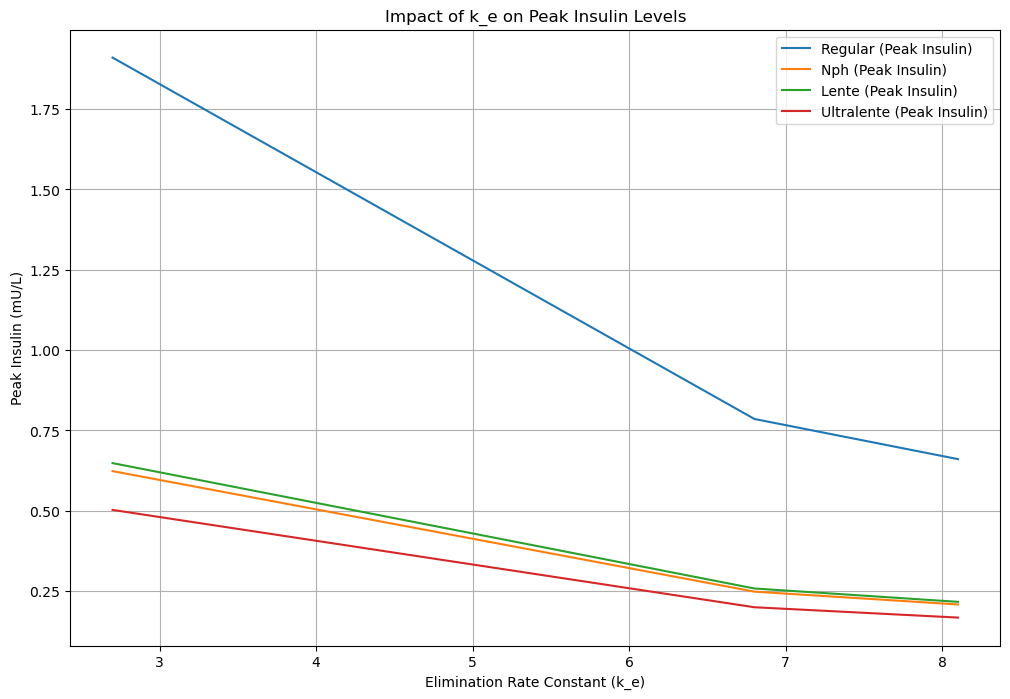

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import simps  # For AUC calculation

# Parameters for each insulin type
params = {
    'regular': [2.0, 0.05, 1.7],
    'NPH': [2.0, 0.18, 4.9],
    'lente': [2.4, 0.15, 6.2],
    'ultralente': [2.5, 0.0, 13.0]
}

# Common parameters
dose = 24  # Insulin dose
k_e_values = [2.7, 6.8, 8.1]  # Range of k_e values for analysis
t = np.linspace(0, 24, 1000)  # Time from 0 to 24 hours

# Function to solve the plasma insulin ODE
def plasma_insulin_ode(t, A, T_50, s, k_e, dose):
    absorption_rate = (s * t**(s-1) * (T_50)**s * dose) / ((T_50**s + t**s)**2)
    return absorption_rate - k_e * A

# Storage for results
analysis_results = []

# Loop over each insulin type
for insulin_type, (s, a, b) in params.items():
    # Calculate T_50
    T_50 = a * dose + b

    # Storage for this insulin type
    insulin_results = []

    # Loop over k_e values
    for k_e in k_e_values:
        # Solve ODE
        sol = solve_ivp(
            plasma_insulin_ode, [0, 24], [0],
            t_eval=t, args=(T_50, s, k_e, dose)
        )
        plasma_insulin = sol.y[0]

        # Calculate metrics
        peak_insulin = np.max(plasma_insulin)
        time_to_peak = t[np.argmax(plasma_insulin)]
        auc = simps(plasma_insulin, t)  # Area under the curve

        # Store results
        insulin_results.append({
            'k_e': k_e,
            'peak_insulin': peak_insulin,
            'time_to_peak': time_to_peak,
            'auc': auc
        })

    # Add results for this insulin type
    analysis_results.append({
        'insulin_type': insulin_type,
        'results': insulin_results
    })

# Display the results
for insulin in analysis_results:
    print(f"Insulin Type: {insulin['insulin_type'].capitalize()}")
    for result in insulin['results']:
        print(f"  k_e: {result['k_e']:.2f}, Peak Insulin: {result['peak_insulin']:.2f}, "
              f"Time to Peak: {result['time_to_peak']:.2f} h, AUC: {result['auc']:.2f}")
    print()

# Visualize the results
plt.figure(figsize=(12, 8))

for insulin in analysis_results:
    k_e_vals = [r['k_e'] for r in insulin['results']]
    peak_insulins = [r['peak_insulin'] for r in insulin['results']]
    aucs = [r['auc'] for r in insulin['results']]

    # Plot Peak Insulin vs. k_e
    plt.plot(k_e_vals, peak_insulins, label=f"{insulin['insulin_type'].capitalize()} (Peak Insulin)")

# Customize plot
plt.xlabel("Elimination Rate Constant (k_e)")
plt.ylabel("Peak Insulin (mU/L)")
plt.title("Impact of k_e on Peak Insulin Levels")
plt.legend()
plt.grid(True)
plt.show()


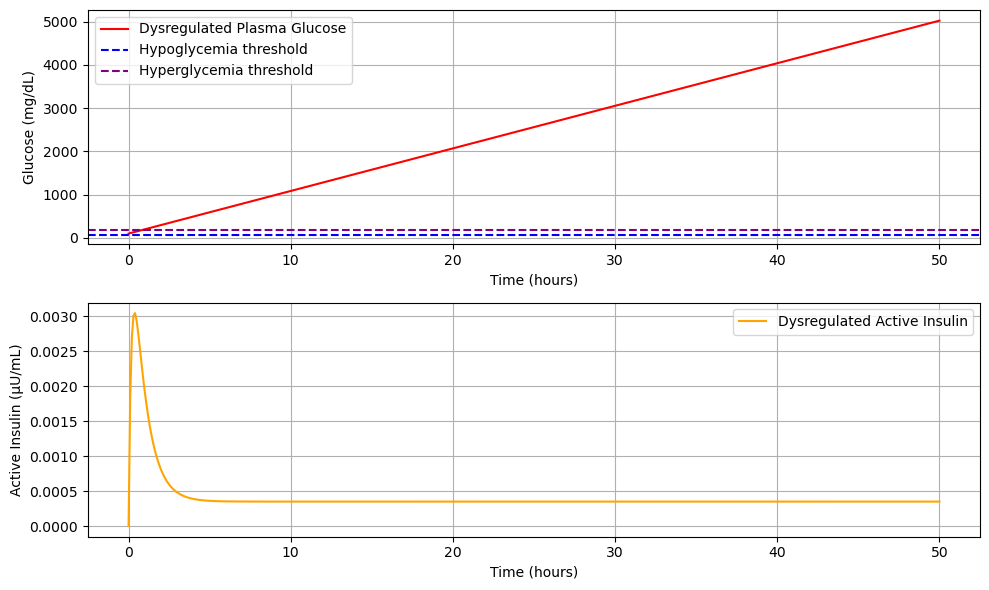

In [7]:
def insulin_glucose_dynamics_dysregulated(t, y):
    A, C, I_e = y

    # Parameters (dysregulated)
    s = 2.0
    a = 0.05
    b = 1.7
    ke = 5.4
    D = 12.0  # Reduced insulin dose
    Km = 30.0  # Impaired glucose utilization
    c = 0.01  # Reduced insulin sensitivity
    d = 1.62
    k1 = 0.025
    k2 = 1.25
    Cin = 100.0  # Increased glucose input
    V_I = 12.0

    # T50 calculation
    T50 = a * D + b

    # Plasma insulin dynamics
    dA_dt = (s * D * T50**s) / ((T50**s + T50**s)**2) - ke * A

    # Glucose dynamics
    Vmax = c * I_e + d
    Cout = (Vmax * C) / (Km + C)
    dC_dt = Cin - Cout

    # Insulin action delay
    dI_e_dt = k1 * A / V_I - k2 * I_e

    return [dA_dt, dC_dt, dI_e_dt]

time_range = (0, 50)  # Simulate from 0 to 50 hours
t_eval = np.linspace(time_range[0], time_range[1], 500)
# Simulate dysregulated dynamics
solution_dysregulated = solve_ivp(
    insulin_glucose_dynamics_dysregulated,
    time_range,
    initial_guess,  # Start with the same initial conditions
    t_eval=t_eval
)

# Extract dysregulated results
A_dysregulated, C_dysregulated, I_e_dysregulated = solution_dysregulated.y

# Plot dysregulated results
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(solution_dysregulated.t, C_dysregulated, label="Dysregulated Plasma Glucose", color="red")
plt.axhline(70, color='blue', linestyle='--', label='Hypoglycemia threshold')
plt.axhline(180, color='purple', linestyle='--', label='Hyperglycemia threshold')
plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(solution_dysregulated.t, I_e_dysregulated, label="Dysregulated Active Insulin", color="orange")
plt.xlabel("Time (hours)")
plt.ylabel("Active Insulin (µU/mL)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


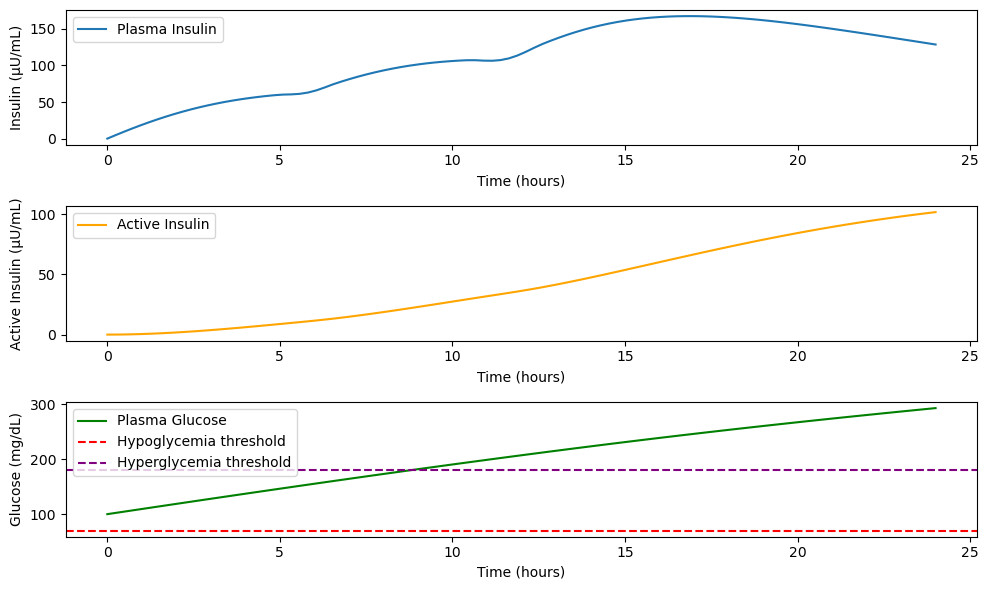

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
T50 = 5  # Half-time of absorption (hours)
s = 2    # Sigmoid sharpness
ke = 0.1  # Insulin elimination rate
k1 = 0.05  # Plasma to active insulin rate
k2 = 0.03  # Active insulin elimination rate
c = 0.045  # Insulin sensitivity
d = 1.62   # Insulin-independent glucose utilization
Km = 180   # Glucose concentration for half-maximal utilization
Vg = 12    # Volume of glucose compartment
Vi = 12    # Volume of insulin compartment
G_in = 10  # Glucose input rate (mg/dL per hour)

# Insulin dose schedule: [(time, dose), ...]
dose_schedule = [(0, 10), (6, 8), (12, 12)]  # Doses at t=0, t=6h, and t=12h

# Function for insulin absorption
def absorption(t):
    """Calculate total insulin absorption at time t based on dose schedule."""
    total_absorption = 0
    for dose_time, dose_amount in dose_schedule:
        if t >= dose_time:  # Only add doses that have been administered
            elapsed = t - dose_time
            total_absorption += dose_amount * s * (1 / (1 + (elapsed / T50)**s))
    return total_absorption

# Differential equations

def insulin_glucose_dynamics(t, y):
    I, Ia, G = y
    # Absorption rate
    abs_rate = absorption(t)
    # Insulin kinetics
    dI_dt = abs_rate - ke * I
    dIa_dt = k1 * I - k2 * Ia
    # Glucose utilization
    Vmax = c * Ia + d
    G_util = Vmax * G / (Km + G)
    dG_dt = G_in - G_util
    return [dI_dt, dIa_dt, dG_dt]

# Time points for simulation
t_span = (0, 24)  # Simulate for 24 hours
t_eval = np.linspace(t_span[0], t_span[1], 100)

# Initial conditions
I0 = 0  # Initial plasma insulin
Ia0 = 0  # Initial active insulin
G0 = 100  # Initial glucose level (mg/dL)

# Solve the system
solution = solve_ivp(
    insulin_glucose_dynamics,
    t_span,
    [I0, Ia0, G0],
    t_eval=t_eval,
    method="RK45"
)

# Extract results
time = solution.t
I, Ia, G = solution.y

# Plot results
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(time, I, label="Plasma Insulin")
plt.xlabel("Time (hours)")
plt.ylabel("Insulin (µU/mL)")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time, Ia, label="Active Insulin", color="orange")
plt.xlabel("Time (hours)")
plt.ylabel("Active Insulin (µU/mL)")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(time, G, label="Plasma Glucose", color="green")
plt.axhline(70, color='red', linestyle='--', label='Hypoglycemia threshold')
plt.axhline(180, color='purple', linestyle='--', label='Hyperglycemia threshold')
plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.legend()

plt.tight_layout()
plt.show()


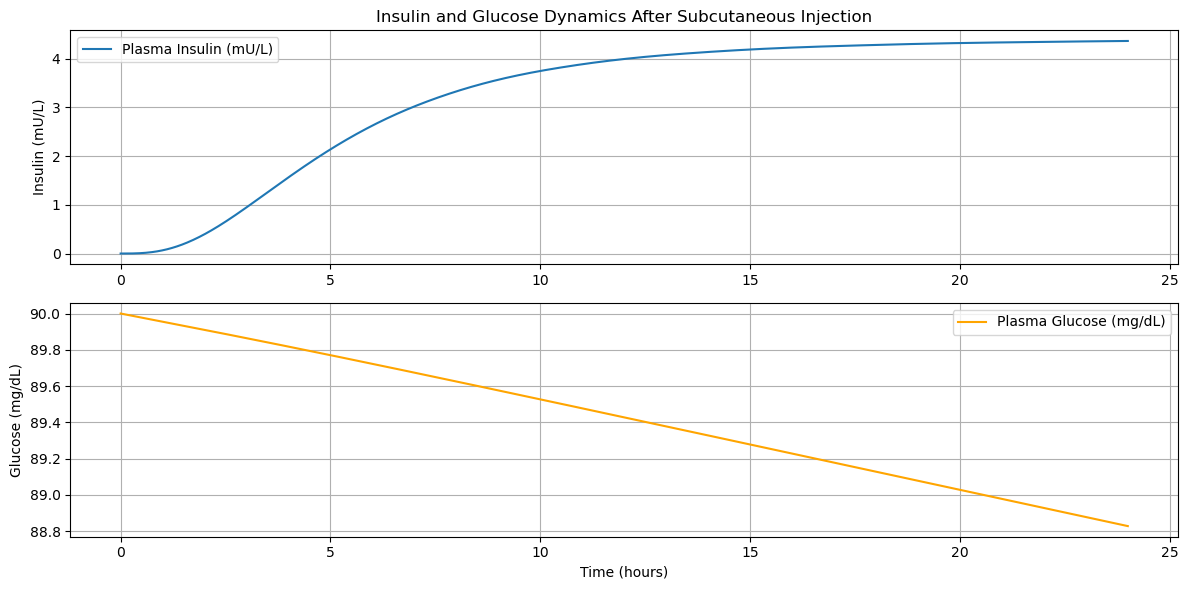

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constants and parameters from the paper
# Insulin parameters
ke = 5.4  # First-order elimination rate constant (h^-1)
Vi = 12   # Distribution volume for insulin (L)

# Glucose parameters
VG = 12  # Distribution volume for glucose (L)
c = 0.045  # Insulin sensitivity (mg/min/kg/mU/L)
d = 1.62  # Insulin-independent glucose utilization (mg/min/kg)
Km = 180  # Glucose concentration for half-maximal response (mg/dL)
BW = 70   # Body weight (kg)

# Time-related parameters for simulations
time_span = (0, 24)  # Simulating over 24 hours
time_points = np.linspace(time_span[0], time_span[1], 1000)

# Logistic equation parameters for insulin absorption (example for regular insulin)
a_reg = 0.05  # Dose-dependent parameter
b_reg = 1.7   # Time parameter
s_reg = 2.0   # Shape parameter

# Helper functions
def insulin_absorption(t, dose, a, b, s):
    """Sigmoidal absorption of insulin."""
    T50 = a * dose + b
    A_abs = 100 - 100 / (1 + (t / T50) ** s)
    return A_abs / 100 * dose

def glucose_utilization(glucose, insulin, c, d, Km):
    """Glucose utilization based on plasma glucose and insulin levels."""
    vmax = c * insulin + d
    return vmax * glucose / (Km + glucose)

# Initial conditions: starting insulin and glucose levels
initial_insulin = 0  # mU/L
initial_glucose = 90  # mg/dL

# Dose and injection timing (example)
insulin_dose = 24  # U
injection_time = 0  # Time of injection in hours

# ODE system for simulation
def system(t, y, dose, a, b, s, ke, Vi, VG, c, d, Km):
    insulin, glucose = y
    absorption_rate = insulin_absorption(t, dose, a, b, s)
    insulin_change = absorption_rate - ke * insulin
    glucose_change = -glucose_utilization(glucose, insulin, c, d, Km) / VG
    return [insulin_change / Vi, glucose_change]

# Solving the system
solution = solve_ivp(
    system, time_span, [initial_insulin, initial_glucose], t_eval=time_points,
    args=(insulin_dose, a_reg, b_reg, s_reg, ke, Vi, VG, c, d, Km)
)

# Plotting results
insulin_profile = solution.y[0]
glucose_profile = solution.y[1]

plt.figure(figsize=(12, 6))

# Insulin profile
plt.subplot(2, 1, 1)
plt.plot(solution.t, insulin_profile, label="Plasma Insulin (mU/L)")
plt.title("Insulin and Glucose Dynamics After Subcutaneous Injection")
plt.ylabel("Insulin (mU/L)")
plt.legend()
plt.grid()

# Glucose profile
plt.subplot(2, 1, 2)
plt.plot(solution.t, glucose_profile, label="Plasma Glucose (mg/dL)", color="orange")
plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# Glucose Homeostasis in the Model
Glucose homeostasis refers to the body's ability to maintain blood glucose levels within a narrow and healthy range despite changes in diet, physical activity, or metabolic demands. In the context of this model, it describes the dynamic interplay between glucose levels (G), insulin levels (A), and active insulin $(I_a)$
## Key Components

1. **Glucose Input $G_in$**:
   - Represents the amount of glucose entering the bloodstream (e.g., from food intake).

2. **Glucose Utilization d**:
   - Describes the baseline rate at which glucose is used by the body, independent of insulin.
   - Includes glucose uptake by the brain and other tissues.

3. **Insulin Action ($A$ and $I_a$)**:
   - **Plasma Insulin A**: Insulin released into the bloodstream to promote glucose uptake by tissues.
   - **Active Insulin $I_a$**: Represents delayed insulin effects, accounting for receptor binding and cellular signaling.

4. **Glucose Elimination**:
   - Insulin-dependent glucose clearance: $ c * \frac{A}{V_I}$
   - Reflects the sensitivity of tissues to insulin c and the volume of insulin distribution $(V_I)$.

---

## Governing Equation for Glucose Dynamics

The glucose dynamics are governed by:
$$\frac{dG}{dt} = C_{\text{in}} - \frac{\left(c \cdot \frac{A}{V_I} + d\right) \cdot (K_m + C_x)}{K_m + G}$$
Where:
- $C_{\text{in}}$: Glucose input.
- c: Insulin sensitivity.
- A: Plasma insulin.
- d: Baseline glucose utilization.
- $K_m$, $G_x$: Parameters affecting glucose clearance.

---

## Maintaining Glucose Homeostasis

### Steady-State Behavior

At steady state $\frac{dG}{dt} = 0$:
$$C_{\text{in}} = \frac{\left(c \cdot \frac{A_s}{V_I} + d\right) \cdot (K_m + C_x)}{K_m + G_s}$$
Where:
- $A_s$, $G_s$: Steady-state plasma insulin and glucose.
- The system balances glucose input with insulin-dependent and independent clearance.

### Stability Analysis

The stability of glucose homeostasis depends on the eigenvalue:
$$\lambda_2 = \frac{(K_m + C_x) \cdot \left(c \cdot \frac{A_s}{V_I} + d\right)}{(K_m + G_s)^2}$$

1. **Negative Eigenvalues $\lambda_2 < 0$**:
   - Stable glucose dynamics: Small perturbations in glucose decay over time.

2. **Positive Eigenvalues $\lambda_2 > 0$**:
   - Unstable glucose dynamics: Small perturbations grow, destabilizing glucose levels.

---

## Parameter Sensitivity

1. **Insulin Sensitivity (c)**:
   - **Effect**: Increasing c raises $\lambda_2$, potentially destabilizing glucose dynamics despite improving clearance.
   - **Physiological Insight**: Excessive insulin sensitivity could lead to hypoglycemia.

2. **Glucose Utilization (d)**:
   - **Effect**: Increasing (d) raises $\lambda_2$, destabilizing glucose dynamics.
   - **Physiological Insight**: High metabolic demand increases instability if insulin sensitivity is insufficient.

3. **Steady-State Glucose $(G_s)$**:
   - **Effect**: Increasing $G_s$ lowers $\lambda_2$, stabilizing glucose dynamics.
   - **Physiological Insight**: Elevated $G_s$ buffers fluctuations but is unhealthy long-term.

---

## Practical Implications

1. **To Stabilize the System**:
   - Increase $G_s$(within healthy limits).
   - Maintain a balance between \(c\) (insulin sensitivity) and \(d\) (glucose utilization).

2. **To Avoid Instability**:
   - Avoid excessive glucose utilization (d) without sufficient insulin sensitivity (c).
   - Ensure efficient insulin elimination $k_e$ and active insulin decay $k_2$.

---

This model highlights how glucose homeostasis depends on the interplay of insulin sensitivity, glucose utilization, and steady-state levels. The eigenvalues reveal whether the system is stable or prone to instability, guiding potential interventions.


Stability Analysis:

1. $\lambda_{1} = - 0.03$
-  corresponds to the active insulin $(I_a)$ decay dynamics $(-k_2)$
- It is negative, meaning this component of the system is stable, and perturbations in $(I_a)$ decay exponentially over time

2. $\lambda_{2} = 0.00304787$
- corresponds to glucose-insulin interaction dynamics
- Since it's positibe, it indicated local instability:
- Perturbations in glucose dynamics grow exponentially at a rate proportional to 0.00304787
- This could represent potential failure in the regulation of glucose levels, such as hyperglycemia or hypoglycemia

3. $\lambda_{3} = -0.1$
- corresponds to the plasma insulin $(A)$ decay dynamics $(-k_e)$
- It's negative, so the system is stable and perturbations in A decay exponentially over time.

Since $\lambda_{2}$ is positive, the entire system is locally unstable. 
The instability in glucose dynamics suggests a regulatory issue. For example:
- If the system represents a diabetic condition, the instability could explain difficulties in maintaining glucose homeostasis.
- In clinical terms, it highlights the need for external insulin administration or lifestyle modifications to stabilize glucose levels.
$$\lambda_{2} = \frac{(K_m + G_x)* (c * \frac{A}{V_I} + d)}{(K_m + G)^2}$$
We still focus on this eigenvalue and adjust paramters to reduce the positie eigenvalue. 
Parameter Sensitivity analysis, we will focus on insulin sensitivity (c) and glucose utilization (d)

1. Higher (c): 
- increases the numerator
- Higher c improves glucose clearance but can make the system less stable (high eigenvalue)
- This typically stabilizes glucose levels, but in this model, it increases which could imply faster glucose uptake
- shows the importance of insulin sensitivity in maintaining glucose homeostasis: In real systems, excessive insulin sensitivity could lead to hypoglycemia, particularly if glucose utilization (d) is also high.

2. Higher (d):
- d appears in the numerator, so increasing d increases $\lambda_{2}$
- increases $\lambda_{2}$, potentially destabilizing glucose dynamics
- excessive glucose utilization without sufficient insulin sensitivity can destabilize the system. Excessive glucose utilization can destabilize glucose levels if insulin sensitivity is not high enough

3. Steady State Glucose $G_s$:
- $G_s$ appears in the denominator squared, so increasing this decreases $\lambda_{2}$
- Higher $G_s$ stabilizes glucose dynamics by reducing $\lambda_{2}$

THERE ARE OTHER PARAMETERS TOO THAT CAN BE CONSIDERED LIKE $K_e, K_2$

Thus, 
Stabilizing Parameters:
- Higher $G_s$: reduces $\lambda_{2} and stabilizes glucose dynamics$
- Higher $k_e, k_2$: ensure faster stabilization of insulin and active insulin dynamics

Destabilizing Parameters:
- Higher c: increases $\lambda_{2}$, destabilizing glucose dynamics dispite improving glucose clearance
- Higher d: increases $\lambda_{2}$, destabilizing glucose dynamics due to increased glucose utilization

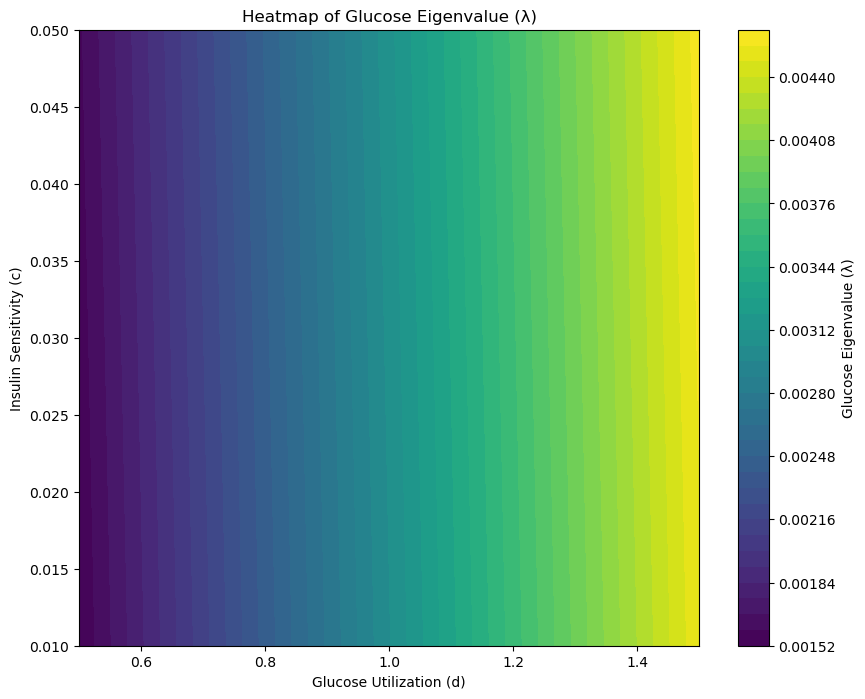

[[0.00152393 0.00158552 0.0016471  ... 0.00441845 0.00448004 0.00454162]
 [0.00152517 0.00158675 0.00164834 ... 0.00441968 0.00448127 0.00454286]
 [0.0015264  0.00158798 0.00164957 ... 0.00442092 0.0044825  0.00454409]
 ...
 [0.00158182 0.00164341 0.00170499 ... 0.00447634 0.00453793 0.00459951]
 [0.00158306 0.00164464 0.00170623 ... 0.00447757 0.00453916 0.00460075]
 [0.00158429 0.00164587 0.00170746 ... 0.00447881 0.00454039 0.00460198]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the system parameters
params = {
    "s": 2.0,
    "T50": 4.0,
    "D": 10.0,
    "k_e": 0.1,
    "c": 0.02,  # Insulin sensitivity
    "d": 1.0,   # Glucose utilization
    "Km": 200.0,
    "C_x": 90.0,
    "V_I": 10.0,
    "k1": 0.05,
    "k2": 0.03,
    "C_in": 100.0,
    "A_s": 5.0,
    "G_s": 110.0,
    "I_a_s": 2.0
}

# Extract constants
C_x, Km, V_I = params["C_x"], params["Km"], params["V_I"]

# Define a function to compute the glucose eigenvalue
def glucose_eigenvalue(c, d, A_s, G_s):
    numerator = (Km + C_x) * (c * (A_s / V_I) + d)
    denominator = (Km + G_s) ** 2
    return numerator / denominator

# Define ranges for c and d
c_values = np.linspace(0.01, 0.05, 50)  # Insulin sensitivity
d_values = np.linspace(0.5, 1.5, 50)   # Glucose utilization

# Create a grid of eigenvalues
eigenvalues = np.zeros((len(c_values), len(d_values)))

for i, c in enumerate(c_values):
    for j, d in enumerate(d_values):
        eigenvalues[i, j] = glucose_eigenvalue(c, d, params["A_s"], params["G_s"])

# Plot the results as a heatmap
plt.figure(figsize=(10, 8))
plt.contourf(d_values, c_values, eigenvalues, levels=50, cmap="viridis")
plt.colorbar(label="Glucose Eigenvalue (λ)")
plt.xlabel("Glucose Utilization (d)")
plt.ylabel("Insulin Sensitivity (c)")
plt.title("Heatmap of Glucose Eigenvalue (λ)")
plt.show()

